In [3]:
import pandas as pd

df = pd.read_csv(r"C:\SearchRankingSystem\Search-Ranking-System\data\processed\processed_data.csv")

products = df[
    [
        "previous_purchase_count",
        "average_order_value",
        "price",
        "discount_percent",
        "stock_available",
        "rating",
        "total_reviews",
        "lifetime_sales",
        "bm25_score",
        "rank_position",
        "query_length",
        "title_length",
        "text_similarity",
        "query_product_relevance",   # <-- Add this
        "membership",
        "country",
        "device_type",
        "brand",
        "category"
    ]
].drop_duplicates()

products.to_csv(r"C:\SearchRankingSystem\Search-Ranking-System\data/products.csv", index=False)

KeyError: "['query_length', 'title_length', 'text_similarity'] not in index"

In [4]:
import pandas as pd 
df=pd.read_csv(r"C:\SearchRankingSystem\Search-Ranking-System\data\raw\raw_data.csv")
df.columns

Index(['user_id', 'membership', 'country', 'previous_purchase_count',
       'average_order_value', 'session_id', 'query', 'device_type',
       'search_time', 'product_id', 'product_title', 'brand', 'category',
       'price', 'discount_percent', 'stock_available', 'rating',
       'total_reviews', 'lifetime_sales', 'rank_position', 'bm25_score',
       'tfidf_similarity', 'query_product_relevance', 'clicked',
       'added_to_cart', 'purchased'],
      dtype='object')

In [5]:
df.shape

(200000, 26)

In [3]:
df['tfidf_similarity']

0         0.950
1         0.011
2         1.000
3         0.565
4         1.000
          ...  
199995    0.104
199996    0.590
199997    0.007
199998    0.033
199999    0.144
Name: tfidf_similarity, Length: 200000, dtype: float64

In [2]:
df.isnull().sum()

user_id                    0
membership                 0
country                    0
previous_purchase_count    0
average_order_value        0
session_id                 0
query                      0
device_type                0
search_time                0
product_id                 0
product_title              0
brand                      0
category                   0
price                      0
discount_percent           0
stock_available            0
rating                     0
total_reviews              0
lifetime_sales             0
rank_position              0
bm25_score                 0
tfidf_similarity           0
query_product_relevance    0
clicked                    0
added_to_cart              0
purchased                  0
dtype: int64

In [3]:
df.columns

Index(['user_id', 'membership', 'country', 'previous_purchase_count',
       'average_order_value', 'session_id', 'query', 'device_type',
       'search_time', 'product_id', 'product_title', 'brand', 'category',
       'price', 'discount_percent', 'stock_available', 'rating',
       'total_reviews', 'lifetime_sales', 'rank_position', 'bm25_score',
       'tfidf_similarity', 'query_product_relevance', 'clicked',
       'added_to_cart', 'purchased'],
      dtype='object')

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,user_id,previous_purchase_count,average_order_value,session_id,product_id,price,discount_percent,stock_available,rating,total_reviews,lifetime_sales,rank_position,bm25_score,tfidf_similarity,query_product_relevance,clicked,added_to_cart,purchased
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,498.983900,154.369600,76110.328483,10000.500000,2496.355575,42539.077245,25.113505,500.198305,4.247453,50356.588970,249129.368200,5.500000,0.600057,0.192660,0.437099,0.269740,0.121545,0.048320
std,288.843383,86.421223,43104.872859,5773.517118,1443.949720,57456.438474,14.779646,289.443928,0.437335,28754.734603,144805.417126,2.872289,0.231077,0.219027,0.163797,0.443826,0.326760,0.214442
min,1.000000,0.000000,180.600000,1.000000,1.000000,326.000000,0.000000,0.000000,3.500000,17.000000,188.000000,1.000000,0.200000,0.000000,0.120000,0.000000,0.000000,0.000000
25%,250.000000,80.000000,37556.000000,5000.750000,1245.000000,6131.000000,12.000000,250.000000,3.900000,25270.000000,124249.000000,3.000000,0.400000,0.070000,0.304000,0.000000,0.000000,0.000000
50%,497.000000,153.000000,77705.000000,10000.500000,2491.000000,18315.000000,25.000000,505.000000,4.200000,51057.000000,248364.000000,5.500000,0.600000,0.140000,0.434000,0.000000,0.000000,0.000000
75%,747.000000,229.000000,113022.000000,15000.250000,3749.000000,49993.000000,38.000000,754.000000,4.600000,75007.000000,373967.000000,8.000000,0.800000,0.210000,0.557000,1.000000,0.000000,0.000000
max,1000.000000,340.000000,149882.000000,20000.000000,5000.000000,299569.000000,50.000000,1000.000000,5.000000,99983.000000,499970.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.describe(include='object')

,membership,country,query,device_type,search_time,product_title,brand,category
count,200000,200000,200000,200000,200000,200000,200000,200000
unique,2,5,30,3,19995,545,27,11
top,Non-Prime,USA,wireless keyboard,Desktop,2025-10-05 14:26:03,Apple Smart Watch,Samsung,Keyboard
freq,102410,41790,7110,67170,20,5516,19214,20210


In [7]:
#Total number of unique users.
df["user_id"].unique().sum()

np.int64(500500)

In [8]:
#Number of Prime vs Non-Prime users.
(df["membership"] == "Prime").sum(),(df["membership"] == "Non-Prime").sum()

(np.int64(97590), np.int64(102410))

In [9]:
#Country-wise user count.
df["country"].value_counts()

country
USA        41790
Canada     41300
India      40310
Germany    39150
UK         37450
Name: count, dtype: int64

In [10]:
#Average purchase count by membership.
avg_purchase = df.groupby('membership')['previous_purchase_count'].mean()

print(avg_purchase)

membership
Non-Prime    157.244410
Prime        151.352803
Name: previous_purchase_count, dtype: float64


In [11]:
#Top 10 users with highest previous purchases.
df.sort_values(by="previous_purchase_count",ascending=False).head(10)

,user_id,membership,country,previous_purchase_count,average_order_value,session_id,query,device_type,search_time,product_id,...,rating,total_reviews,lifetime_sales,rank_position,bm25_score,tfidf_similarity,query_product_relevance,clicked,added_to_cart,purchased
196188,3,Prime,USA,340,1450.25,14544,ram,Tablet,2025-04-06 16:39:28,4904,...,3.7,29215,260672,4,0.911,0.056,0.569,0,0,0
38966,3,Prime,USA,340,1450.25,7488,smart watch,Tablet,2025-05-01 17:35:40,973,...,4.0,44409,283518,2,0.448,0.226,0.359,1,0,0
22855,3,Prime,USA,340,1450.25,5192,apple watch,Mobile,2025-03-23 00:53:02,569,...,3.9,12581,26123,3,0.326,0.166,0.262,0,0,0
61251,3,Prime,USA,340,1450.25,9062,ssd,Desktop,2025-04-18 07:07:51,1529,...,4.1,40098,237918,1,0.648,0.238,0.484,0,0,0
114688,3,Prime,USA,340,1450.25,1443,android phone,Mobile,2025-06-03 20:53:40,2860,...,4.8,7269,272864,10,0.554,0.038,0.348,0,0,0
38653,3,Prime,USA,340,1450.25,14544,ram,Tablet,2025-04-06 16:39:28,965,...,4.8,67662,354894,5,0.668,0.130,0.453,0,0,0
194854,3,Prime,USA,340,1450.25,17295,camera,Mobile,2025-02-23 15:14:21,4870,...,4.1,96344,487280,4,0.749,1.000,0.849,0,0,0
194794,3,Prime,USA,340,1450.25,11108,ssd,Tablet,2025-06-14 19:48:24,4869,...,4.9,52639,417375,10,0.480,0.232,0.381,0,0,0
108327,3,Prime,USA,340,1450.25,4664,laptop,Desktop,2025-01-10 17:33:24,2699,...,4.7,40553,349409,4,0.539,0.238,0.419,1,0,0
116149,3,Prime,USA,340,1450.25,5564,camera,Mobile,2025-10-24 19:51:57,2896,...,4.5,82189,75412,7,0.454,0.128,0.324,0,0,0


In [12]:
#User having maximum average order value.
#df.sort_values(by='average_order_value',ascending=False).head(10)
df.nlargest(10, 'average_order_value')

,user_id,membership,country,previous_purchase_count,average_order_value,session_id,query,device_type,search_time,product_id,...,rating,total_reviews,lifetime_sales,rank_position,bm25_score,tfidf_similarity,query_product_relevance,clicked,added_to_cart,purchased
2829,166,Non-Prime,USA,237,149882.0,9808,laptop,Desktop,2025-09-15 03:48:41,70,...,4.1,87072,482849,5,0.547,1.000,0.728,1,1,1
3451,166,Non-Prime,USA,237,149882.0,1418,mechanical keyboard,Desktop,2025-01-22 10:36:08,86,...,4.0,70808,42345,2,0.881,0.074,0.558,0,0,0
6686,166,Non-Prime,USA,237,149882.0,16926,gaming accessories,Mobile,2025-11-20 23:28:17,164,...,4.5,60991,472593,10,0.997,0.560,0.822,1,0,0
8252,166,Non-Prime,USA,237,149882.0,1418,mechanical keyboard,Desktop,2025-01-22 10:36:08,202,...,4.5,62173,35297,10,0.783,0.070,0.498,0,0,0
12867,166,Non-Prime,USA,237,149882.0,1646,ssd,Tablet,2025-04-09 15:22:28,318,...,4.3,65556,21205,5,0.485,0.167,0.358,1,0,0
16001,166,Non-Prime,USA,237,149882.0,7485,ram,Mobile,2025-01-25 01:39:45,395,...,4.9,71068,336592,5,0.823,0.159,0.557,1,1,0
16140,166,Non-Prime,USA,237,149882.0,12388,smart watch,Desktop,2025-10-05 10:07:22,398,...,4.5,80818,478644,10,0.815,0.207,0.572,1,0,0
17003,166,Non-Prime,USA,237,149882.0,9808,laptop,Desktop,2025-09-15 03:48:41,421,...,3.8,49913,88967,4,0.210,1.000,0.526,0,0,0
20863,166,Non-Prime,USA,237,149882.0,16926,gaming accessories,Mobile,2025-11-20 23:28:17,519,...,3.9,5764,483113,7,0.965,0.084,0.613,1,0,0
22294,166,Non-Prime,USA,237,149882.0,7485,ram,Mobile,2025-01-25 01:39:45,555,...,4.6,38612,66867,2,0.542,0.108,0.368,0,0,0


In [13]:
#Average order value country-wise.
avg_order = df.groupby('country')['average_order_value'].mean()
print(avg_order)

country
Canada     81813.319177
Germany    74290.348659
India      73618.500682
UK         69683.770414
USA        80341.935870
Name: average_order_value, dtype: float64


In [14]:
#Country having highest average order value.
df.groupby('country')['average_order_value'].max().head(1)

country
Canada    149645.0
Name: average_order_value, dtype: float64

In [15]:
df['purchased'].value_counts()

purchased
0    190336
1      9664
Name: count, dtype: int64

In [16]:
#Average purchase count for each country.
df.groupby('country')['purchased'].mean()

country
Canada     0.049903
Germany    0.050268
India      0.048003
UK         0.046729
USA        0.046662
Name: purchased, dtype: float64

In [17]:
#Total number of sessions.
df['session_id'].sum()

np.int64(2000100000)

In [18]:
#Number of searches made from each device.
df.groupby('device_type')['query'].count()

device_type
Desktop    67170
Mobile     67000
Tablet     65830
Name: query, dtype: int64

In [19]:
#Most frequently searched query.
df['query'].value_counts().head(1)

query
wireless keyboard    7110
Name: count, dtype: int64

In [20]:
#Top 10 most searched queries.
df['query'].value_counts().head(10)

query
wireless keyboard       7110
1tb ssd                 7040
camera                  7030
bluetooth headphones    6960
android phone           6830
ram                     6810
monitor                 6810
samsung phone           6800
24 inch monitor         6730
headphones              6730
Name: count, dtype: int64

In [21]:
#Average number of searches per user.
df['user_id'].value_counts().mean()

np.float64(200.0)

In [22]:
#***Peak search hour.
df['search_time'] = pd.to_datetime(df['search_time'])

df['search_time'].dt.hour.value_counts().sort_index()

search_time
0     8940
1     8230
2     8320
3     8670
4     8260
5     8320
6     8070
7     7680
8     7850
9     7960
10    8250
11    7880
12    8370
13    8030
14    8470
15    8600
16    8850
17    8230
18    8790
19    8770
20    8170
21    8450
22    8490
23    8350
Name: count, dtype: int64

In [23]:
#Searches by day of week.
#df['search_time'].dt.day_of_week
df['search_time'].dt.day_name().value_counts()

search_time
Friday       29220
Sunday       29060
Wednesday    28860
Thursday     28510
Saturday     28240
Monday       28140
Tuesday      27970
Name: count, dtype: int64

In [24]:
#Device used most by Prime members.
df[df['membership'] == 'Prime']['device_type'].value_counts()

device_type
Tablet     32730
Mobile     32480
Desktop    32380
Name: count, dtype: int64

In [25]:
#Number of unique products.
df['product_id'].nunique()

5000

In [26]:
#Number of products in each category.
df.groupby('category')['product_id'].count()

category
Camera         19850
Electronics      227
Headphones     20092
Keyboard       20210
Laptop         19925
Mobile         19883
Monitor        19860
Mouse          20058
RAM            19907
SSD            19860
Smartwatch     20128
Name: product_id, dtype: int64

In [27]:
#Average price of each category.
df.groupby('category')['price'].mean()

category
Camera         165562.917834
Electronics     88994.594714
Headphones      10501.714264
Keyboard         3941.318308
Laptop          96071.819021
Mobile          65402.062113
Monitor         27387.240282
Mouse            2614.802573
RAM             15330.757020
SSD             13364.240181
Smartwatch      26279.490461
Name: price, dtype: float64

In [28]:
#Most expensive product.
df.groupby('product_title')['price'].max().head(1),
#Cheapest product.
df.groupby('product_title')['price'].min().head(1)

product_title
Acer 24 inch Monitor    7160.0
Name: price, dtype: float64

In [29]:
#Top 10 highest rated products.
df.groupby('product_title')['rating'].max().sort_values(ascending=False).head(10)

product_title
Xiaomi Smartphone 332GB     5.0
Xiaomi Smartphone 152GB     5.0
Xiaomi Smartphone 190GB     5.0
Xiaomi Smartphone 252GB     5.0
Sony Wireless Headphones    5.0
WD SSD 1024GB               5.0
WD SSD 256GB                5.0
Apple Smartphone 330GB      5.0
Samsung Smartphone 498GB    5.0
Samsung Smartphone 475GB    5.0
Name: rating, dtype: float64

In [30]:
#Products having rating below 4.
df[df['rating'] <4][['product_title', 'rating']]

,product_title,rating
272,HP Gaming Laptop 16 inch,3.7
273,HP Gaming Laptop 16 inch,3.7
274,HP Gaming Laptop 16 inch,3.7
275,HP Gaming Laptop 16 inch,3.7
276,HP Gaming Laptop 16 inch,3.7
...,...,...
199709,Nikon DSLR Camera,3.9
199710,Nikon DSLR Camera,3.9
199711,Nikon DSLR Camera,3.9
199712,Nikon DSLR Camera,3.9


In [31]:
#Average discount by category.
df.groupby('category')['discount_percent'].mean()

category
Camera         25.125844
Electronics    11.907489
Headphones     25.588642
Keyboard       24.784463
Laptop         26.261581
Mobile         25.241815
Monitor        24.283233
Mouse          25.502243
RAM            23.899332
SSD            25.259718
Smartwatch     25.331528
Name: discount_percent, dtype: float64

In [32]:
#Brand with highest number of products
df.groupby('brand')['product_id'].count().sort_values(ascending=False).head(10)

brand
Samsung     19214
Dell        17999
Apple       13628
HP          12553
Logitech    10354
Crucial     10324
Kingston     9383
Noise        9079
Sony         8887
Acer         8766
Name: product_id, dtype: int64

In [33]:
#Top 10 brands by lifetime sales.
df.groupby('brand')['lifetime_sales'].sum().sort_values(ascending=False).head(10)

brand
Samsung     4545486327
Dell        4455632565
Apple       3547980849
HP          2993555361
Crucial     2765857389
Logitech    2512878992
Kingston    2354989828
Acer        2337101413
Noise       2232173573
Sony        2148133220
Name: lifetime_sales, dtype: int64

In [34]:
#Products out of stock.
df[df['stock_available']==0][['product_title','stock_available']]

,product_title,stock_available
19221,Asus Gaming Laptop 13 inch,0
19222,Asus Gaming Laptop 13 inch,0
19223,Asus Gaming Laptop 13 inch,0
19224,Asus Gaming Laptop 13 inch,0
19225,Asus Gaming Laptop 13 inch,0
...,...,...
182384,Fujifilm DSLR Camera,0
182385,Fujifilm DSLR Camera,0
182386,Fujifilm DSLR Camera,0
182387,Fujifilm DSLR Camera,0


In [35]:
#Products having stock greater than 100.
df[df['stock_available']>100][['product_title','stock_available']]

,product_title,stock_available
227,HP Gaming Laptop 16 inch,826
228,HP Gaming Laptop 16 inch,826
229,HP Gaming Laptop 16 inch,826
230,HP Gaming Laptop 16 inch,826
231,HP Gaming Laptop 16 inch,826
...,...,...
199995,Nikon DSLR Camera,177
199996,Nikon DSLR Camera,177
199997,Nikon DSLR Camera,177
199998,Nikon DSLR Camera,177


In [36]:
#Category generating highest lifetime sales.
df.groupby('category')['lifetime_sales'].sum().sort_values(ascending=False).head(10)

category
Camera        5116861011
SSD           5100898109
Headphones    5046637680
Mouse         5026362378
Keyboard      5001703132
Smartwatch    4989212738
Laptop        4909472125
RAM           4908058771
Monitor       4885346445
Mobile        4828339251
Name: lifetime_sales, dtype: int64

In [37]:
#Average BM25 score.
df['bm25_score'].mean()

np.float64(0.60005737)

In [38]:
#Product having highest relevance score.
df.groupby('product_title')['query_product_relevance'].max().sort_values(ascending=False).head(1)

product_title
WD SSD 256GB    1.0
Name: query_product_relevance, dtype: float64

In [39]:
#Average relevance score by category.
df.groupby('category')['query_product_relevance'].mean().sort_values(ascending=False)

category
Electronics    0.485022
Laptop         0.460756
Headphones     0.455212
Monitor        0.446050
Mouse          0.441316
SSD            0.440615
Camera         0.439803
Keyboard       0.429320
Smartwatch     0.429318
RAM            0.414763
Mobile         0.413277
Name: query_product_relevance, dtype: float64

In [40]:
#Correlation between BM25 and relevance score.
df[['bm25_score', 'query_product_relevance']].corr()

,bm25_score,query_product_relevance
bm25_score,1.000000,0.844926
query_product_relevance,0.844926,1.000000


In [41]:
#Correlation between TF-IDF and relevance score.
df[['tfidf_similarity', 'query_product_relevance']].corr()

,tfidf_similarity,query_product_relevance
tfidf_similarity,1.000000,0.532454
query_product_relevance,0.532454,1.000000


In [42]:
#Average rank position.
df['rank_position'].mean()

np.float64(5.5)

In [43]:
#Number of products appearing in top 5 ranks.
df[df['rank_position'] <= 5]['product_id'].count()

np.int64(100000)

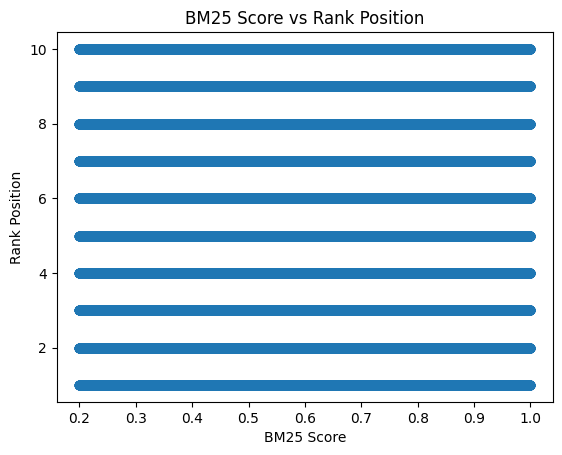

In [44]:
#Does higher BM25 lead to better ranking?
df[['bm25_score', 'rank_position']].corr()
import matplotlib.pyplot as plt

plt.scatter(df['bm25_score'], df['rank_position'])
plt.xlabel('BM25 Score')
plt.ylabel('Rank Position')
plt.title('BM25 Score vs Rank Position')
plt.show()

In [45]:
#Compare relevance scores for clicked vs non-clicked products.
df.groupby('clicked')['query_product_relevance'].mean()

clicked
0    0.397646
1    0.543908
Name: query_product_relevance, dtype: float64

In [46]:
#Total clicks.
df['clicked'].sum()

np.int64(53948)

In [47]:
#***Click Through Rate (CTR).
df['clicked'].mean() * 100

np.float64(26.973999999999997)

In [48]:
#Category-wise CTR.
df.groupby('category')['clicked'].mean() * 100

category
Camera         27.803526
Electronics    25.991189
Headphones     29.205654
Keyboard       25.967343
Laptop         29.651192
Mobile         23.849520
Monitor        28.373615
Mouse          27.749526
RAM            23.956397
SSD            27.462236
Smartwatch     25.735294
Name: clicked, dtype: float64

In [49]:
#Country-wise CTR.
df.groupby('country')['clicked'].mean() * 100

country
Canada     27.082324
Germany    27.197957
India      26.908956
UK         27.012016
USA        26.685810
Name: clicked, dtype: float64

In [50]:
#Average BM25 score for clicked products.
df[df['clicked']==1]['bm25_score'].mean()

np.float64(0.7234539556610069)

In [51]:
#Products with highest clicks.
df.groupby('product_title')['clicked'].sum().sort_values(ascending=False).head(10)

product_title
Apple Smart Watch               1498
Nikon DSLR Camera               1439
Logitech Wireless Mouse         1430
HP Wireless Mouse               1423
Razer Wireless Mouse            1417
Sony DSLR Camera                1416
Dell Mechanical Keyboard        1393
Samsung Smart Watch             1337
Fujifilm DSLR Camera            1334
Logitech Mechanical Keyboard    1333
Name: clicked, dtype: int64

In [52]:
#Queries with highest click rate.
df.groupby('query')['clicked'].sum().sort_values(ascending=False).head(1)

query
wireless keyboard    2155
Name: clicked, dtype: int64

In [53]:
#total add-to-cart events.
df['added_to_cart'].sum()

np.int64(24309)

In [54]:
#Category with highest add-to-cart rate.
df.groupby('category')['added_to_cart'].sum().sort_values(ascending=False).head(1)

category
Laptop    2679
Name: added_to_cart, dtype: int64

In [55]:
#Brand with highest cart additions.
df.groupby('brand')['added_to_cart'].sum().sort_values(ascending=False).head(1)

brand
Samsung    2407
Name: added_to_cart, dtype: int64

In [56]:
#***Products frequently added but not purchased
df[(df['added_to_cart'] == 1) & (df['purchased'] == 0)]['product_title'].value_counts()

product_title
Apple Smart Watch           411
Logitech Wireless Mouse     410
Dell Mechanical Keyboard    394
Nikon DSLR Camera           393
Fujifilm DSLR Camera        392
                           ... 
Xiaomi Smartphone 305GB       1
Xiaomi Smartphone 89GB        1
OnePlus Smartphone 166GB      1
Samsung Smartphone 141GB      1
Lenovo Legion 5               1
Name: count, Length: 517, dtype: int64

In [57]:
#Cart rate by device.
df.groupby('device_type')['added_to_cart'].mean().sort_values(ascending=False)

device_type
Desktop    0.121766
Mobile     0.121657
Tablet     0.121206
Name: added_to_cart, dtype: float64

In [58]:
#Purchase conversion rate.
df['purchased'].mean()

np.float64(0.04832)

In [59]:
#Purchase rate by country.
df.groupby('country')['purchased'].mean().mul(100).sort_values(ascending=False)

country
Germany    5.026820
Canada     4.990315
India      4.800298
UK         4.672897
USA        4.666188
Name: purchased, dtype: float64

In [60]:
#Top 10 purchased products.
df.groupby('product_title')['purchased'].sum().sort_values(ascending=False).head(10)

product_title
Apple Smart Watch               305
Razer Wireless Mouse            277
Sony DSLR Camera                272
Nikon DSLR Camera               260
Apple Wireless Headphones       251
Noise Wireless Headphones       249
Logitech Mechanical Keyboard    246
HP Wireless Mouse               240
Samsung Smart Watch             236
Logitech Wireless Mouse         232
Name: purchased, dtype: int64

In [61]:
#Products viewed but never purchased.
df[(df['clicked']==1) & (df['purchased']==0)][['product_title']]

,product_title
0,HP Victus Gaming Laptop
4,HP Victus Gaming Laptop
5,HP Victus Gaming Laptop
10,HP Victus Gaming Laptop
20,HP Victus Gaming Laptop
...,...
199980,Nikon DSLR Camera
199992,Nikon DSLR Camera
199995,Nikon DSLR Camera
199997,Nikon DSLR Camera


In [62]:
#Prime vs Non-Prime purchase rate.
df.groupby('membership')['purchased'].mean()

membership
Non-Prime    0.048794
Prime        0.047823
Name: purchased, dtype: float64

In [63]:
#Average relevance score of purchased products.
df[df['purchased']==1]['query_product_relevance'].mean()

np.float64(0.5436606995033112)

In [64]:
#Category-wise average price.
df.groupby('category')['price'].mean().sort_values(ascending=False)


category
Camera         165562.917834
Laptop          96071.819021
Electronics     88994.594714
Mobile          65402.062113
Monitor         27387.240282
Smartwatch      26279.490461
RAM             15330.757020
SSD             13364.240181
Headphones      10501.714264
Keyboard         3941.318308
Mouse            2614.802573
Name: price, dtype: float64

In [65]:
#Category-wise stock available.
df.groupby('category')['stock_available'].sum().sort_values(ascending=False)

category
Mouse          10284644
Mobile         10266176
Keyboard       10131448
Laptop         10053339
Smartwatch     10012158
Monitor         9998634
Camera          9936746
RAM             9863149
SSD             9840650
Headphones      9644816
Electronics        7901
Name: stock_available, dtype: int64

In [66]:
#Top product in each category based on sales.
top_products = df.loc[
    df.groupby('category')['lifetime_sales'].idxmax(),
    ['category', 'product_title', 'lifetime_sales']
]

print(top_products)

           category                 product_title  lifetime_sales
196912       Camera             Nikon DSLR Camera          498918
179     Electronics          Apple MacBook Air M3           89000
51141    Headphones       JBL Wireless Headphones          499169
71249      Keyboard  Redragon Mechanical Keyboard          499560
20112        Laptop     MSI Gaming Laptop 13 inch          499970
36113        Mobile      OnePlus Smartphone 262GB          497710
115325      Monitor            LG 32 inch Monitor          499897
91945         Mouse       Logitech Wireless Mouse          498859
155086          RAM             Crucial DDR5 64GB          497454
131177          SSD             Samsung SSD 256GB          498368
174029   Smartwatch             Apple Smart Watch          499043


In [67]:
#Top 20 expensive products.
df.sort_values(
    by=['price', 'product_id'],
    ascending=[False, True]
).head(20)

,user_id,membership,country,previous_purchase_count,average_order_value,session_id,query,device_type,search_time,product_id,...,rating,total_reviews,lifetime_sales,rank_position,bm25_score,tfidf_similarity,query_product_relevance,clicked,added_to_cart,purchased
186111,500,Prime,USA,265,54853.0,1031,dslr camera,Tablet,2025-08-17 02:24:39,4651,...,5.0,9361,329974,3,0.886,1.000,0.932,0,0,0
186112,874,Non-Prime,Germany,116,145623.0,2119,fitness band,Desktop,2025-04-14 04:30:48,4651,...,5.0,9361,329974,10,0.264,0.042,0.175,1,1,0
186113,539,Prime,Canada,78,119769.0,2600,gaming mouse,Desktop,2025-10-28 09:21:06,4651,...,5.0,9361,329974,4,0.331,0.161,0.263,0,0,0
186114,655,Non-Prime,Canada,71,79885.0,2909,wireless mouse,Mobile,2025-04-14 08:54:45,4651,...,5.0,9361,329974,6,0.792,0.187,0.550,0,0,0
186115,845,Prime,USA,177,84259.0,3532,dslr camera,Mobile,2025-09-14 19:50:02,4651,...,5.0,9361,329974,2,0.573,1.000,0.744,1,0,0
186116,283,Prime,UK,111,116730.0,3562,1tb ssd,Tablet,2025-03-10 14:39:53,4651,...,5.0,9361,329974,1,0.755,0.081,0.485,0,0,0
186117,274,Non-Prime,India,119,124094.0,4686,macbook,Tablet,2025-01-09 04:45:49,4651,...,5.0,9361,329974,6,0.456,0.240,0.370,0,0,0
186118,282,Prime,Canada,208,73832.0,5073,samsung phone,Mobile,2025-05-27 17:38:00,4651,...,5.0,9361,329974,4,0.737,0.137,0.497,1,0,0
186119,946,Prime,India,2,65727.0,5076,macbook,Desktop,2025-12-21 15:26:20,4651,...,5.0,9361,329974,10,0.495,0.033,0.310,0,0,0
186120,935,Prime,Canada,271,78712.0,5234,27 inch monitor,Mobile,2025-01-09 16:49:14,4651,...,5.0,9361,329974,2,0.891,0.204,0.616,1,1,0


In [68]:
#Top 20 products by lifetime sales.
df.nlargest(20,'lifetime_sales')[['product_id','product_title','lifetime_sales']]

,product_id,product_title,lifetime_sales
20112,500,MSI Gaming Laptop 13 inch,499970
20113,500,MSI Gaming Laptop 13 inch,499970
20114,500,MSI Gaming Laptop 13 inch,499970
20115,500,MSI Gaming Laptop 13 inch,499970
20116,500,MSI Gaming Laptop 13 inch,499970
20117,500,MSI Gaming Laptop 13 inch,499970
20118,500,MSI Gaming Laptop 13 inch,499970
20119,500,MSI Gaming Laptop 13 inch,499970
20120,500,MSI Gaming Laptop 13 inch,499970
20121,500,MSI Gaming Laptop 13 inch,499970


In [69]:
#Top users by purchase count.
df[['user_id','previous_purchase_count']].sort_values(by='previous_purchase_count',ascending=False).head(20)

,user_id,previous_purchase_count
196188,3,340
38966,3,340
22855,3,340
61251,3,340
114688,3,340
38653,3,340
194854,3,340
194794,3,340
108327,3,340
116149,3,340


In [70]:
#Top brands by average rating.
df.groupby('brand')['rating'].mean().sort_values(ascending=False)

brand
Asus        4.330360
Kingston    4.311489
LG          4.288207
Fujifilm    4.287381
Nikon       4.279280
MSI         4.278088
OnePlus     4.267445
Crucial     4.265265
G.Skill     4.262652
Razer       4.261450
Acer        4.256753
Canon       4.254031
Google      4.253357
Boat        4.251513
Lenovo      4.245319
Apple       4.243198
Dell        4.242852
Sony        4.241161
Xiaomi      4.238758
Samsung     4.238337
Corsair     4.234273
HP          4.227221
Logitech    4.225246
Noise       4.208966
WD          4.205108
JBL         4.189381
Redragon    4.171235
Name: rating, dtype: float64

In [71]:
#Products priced above ₹5,000.
df[df['price']>5000][['product_title','price']]

,product_title,price
0,HP Victus Gaming Laptop,79999.0
1,HP Victus Gaming Laptop,79999.0
2,HP Victus Gaming Laptop,79999.0
3,HP Victus Gaming Laptop,79999.0
4,HP Victus Gaming Laptop,79999.0
...,...,...
199995,Nikon DSLR Camera,290139.0
199996,Nikon DSLR Camera,290139.0
199997,Nikon DSLR Camera,290139.0
199998,Nikon DSLR Camera,290139.0


In [72]:
#Products with discount greater than 30%.
df[df['discount_percent']>30][['product_title','discount_percent']]

,product_title,discount_percent
272,HP Gaming Laptop 16 inch,35
273,HP Gaming Laptop 16 inch,35
274,HP Gaming Laptop 16 inch,35
275,HP Gaming Laptop 16 inch,35
276,HP Gaming Laptop 16 inch,35
...,...,...
199952,Fujifilm DSLR Camera,48
199953,Fujifilm DSLR Camera,48
199954,Fujifilm DSLR Camera,48
199955,Fujifilm DSLR Camera,48


In [73]:
#Prime users from India.
df[(df['membership']=='Prime') & (df['country']=='India')][['user_id','membership','country']]

,user_id,membership,country
0,1,Prime,India
9,905,Prime,India
42,706,Prime,India
45,564,Prime,India
49,1,Prime,India
...,...,...,...
199961,957,Prime,India
199969,803,Prime,India
199979,293,Prime,India
199987,423,Prime,India


In [74]:
# Products with BM25 score above average.
df[(df['bm25_score'])>(df['bm25_score'].mean())][['product_title','bm25_score']]

,product_title,bm25_score
0,HP Victus Gaming Laptop,0.960
1,HP Victus Gaming Laptop,0.779
3,HP Victus Gaming Laptop,0.824
4,HP Victus Gaming Laptop,0.799
5,HP Victus Gaming Laptop,0.842
...,...,...
199988,Nikon DSLR Camera,0.607
199992,Nikon DSLR Camera,0.851
199995,Nikon DSLR Camera,0.776
199996,Nikon DSLR Camera,0.665


In [75]:
#Create a final price column after discount.
df['final_price']=df['price']-(df['price']*df['discount_percent'])/100
print(df['final_price'])

0          67999.15
1          67999.15
2          67999.15
3          67999.15
4          67999.15
            ...    
199995    249519.54
199996    249519.54
199997    249519.54
199998    249519.54
199999    249519.54
Name: final_price, Length: 200000, dtype: float64


In [76]:
#Create a purchase value column.
df['purchase_value']=df['previous_purchase_count']+df['purchased']
print(df['purchase_value'])

0         120
1         296
2         294
3         233
4         112
         ... 
199995    291
199996    207
199997    117
199998    293
199999    295
Name: purchase_value, Length: 200000, dtype: int64


In [77]:
df.columns

Index(['user_id', 'membership', 'country', 'previous_purchase_count',
       'average_order_value', 'session_id', 'query', 'device_type',
       'search_time', 'product_id', 'product_title', 'brand', 'category',
       'price', 'discount_percent', 'stock_available', 'rating',
       'total_reviews', 'lifetime_sales', 'rank_position', 'bm25_score',
       'tfidf_similarity', 'query_product_relevance', 'clicked',
       'added_to_cart', 'purchased', 'final_price', 'purchase_value'],
      dtype='object')

In [78]:
df['purchase_value'].mean()

np.float64(154.41792)

In [79]:
df['average_order_value'].mean()

np.float64(76110.3284825)

In [80]:
#Create a high-value customer flag.
df['high_value_customer_flag'] = (
    (df['average_order_value'] > 76110) &
    (df['previous_purchase_count'] >= 154)
).map({True: 'High Value', False: 'Normal'})
df['high_value_customer_flag']

0             Normal
1             Normal
2         High Value
3         High Value
4             Normal
             ...    
199995    High Value
199996    High Value
199997        Normal
199998    High Value
199999        Normal
Name: high_value_customer_flag, Length: 200000, dtype: object

In [81]:
df['total_reviews'].max()

np.int64(99983)

In [82]:
#Create a popularity score using rating and reviews.
df['popularity_score'] = 0
df.loc[
    (df['rating'] > 4.3) &
    (df['total_reviews'] > 80000),
    'popularity_score'
] = 2
df.loc[
    (df['rating'] > 3.9) &
    (df['total_reviews'] > 50356),
    'popularity_score'
] = 1
df['popularity_score']

0         0
1         0
2         0
3         0
4         0
         ..
199995    1
199996    1
199997    1
199998    1
199999    1
Name: popularity_score, Length: 200000, dtype: int64

In [83]:
df['price'].median()

np.float64(18315.0)

In [84]:
#Bucket prices into Low, Medium, High.
df['bucket_price']='low'
df.loc[
    df['price']>18315,
    'bucket_price'
]='medium'
df.loc[
    df['price']>49993,
    'bucket_price'
]='high'
df['bucket_price']

0         high
1         high
2         high
3         high
4         high
          ... 
199995    high
199996    high
199997    high
199998    high
199999    high
Name: bucket_price, Length: 200000, dtype: object

In [85]:
#Extract hour, day, month from search_time.
df['search_time'].dt.hour.sort_index()
df['search_time'].dt.month.sort_index()
df['search_time'].dt.day.sort_index()

0         22
1          4
2          4
3         20
4         27
          ..
199995     3
199996    13
199997    23
199998    22
199999    14
Name: search_time, Length: 200000, dtype: int32

In [86]:
#Create a revenue column.
df['revenue']=df['previous_purchase_count']*df['final_price']
df['revenue']

0          8159898.00
1         20127748.40
2         19991750.10
3         15775802.80
4          7615904.80
             ...     
199995    72610186.14
199996    51650544.78
199997    29193786.18
199998    73109225.22
199999    73608264.30
Name: revenue, Length: 200000, dtype: float64

In [87]:
#Create a CTR column by product.(ctr=click through rate)
df.groupby('product_title')['clicked'].mean().sort_values(ascending=False)

product_title
Apple Smartphone 399GB      0.424242
Apple Smartphone 303GB      0.400000
Google Smartphone 75GB      0.395349
Apple Smartphone 202GB      0.390244
Apple Smartphone 110GB      0.387755
                              ...   
Google Smartphone 202GB     0.111111
OnePlus Smartphone 419GB    0.104167
Xiaomi Smartphone 333GB     0.100000
Apple Smartphone 281GB      0.093750
Google Smartphone 431GB     0.081081
Name: clicked, Length: 545, dtype: float64

In [88]:
df['purchased']

0         0
1         0
2         0
3         1
4         0
         ..
199995    0
199996    0
199997    0
199998    0
199999    0
Name: purchased, Length: 200000, dtype: int64

In [89]:
#Create a conversion flag.
df['conversion_flag'] = ((df['clicked'] == 1) & (df['purchased'] == 1)).astype(int)
df['conversion_flag']

0         0
1         0
2         0
3         1
4         0
         ..
199995    0
199996    0
199997    0
199998    0
199999    0
Name: conversion_flag, Length: 200000, dtype: int64

In [90]:
#Correlation matrix of numerical columns.
print(df.corr(numeric_only=True))

                              user_id  previous_purchase_count  \
user_id                  1.000000e+00            -5.214717e-03   
previous_purchase_count -5.214717e-03             1.000000e+00   
average_order_value      1.235316e-02            -7.400964e-03   
session_id              -6.123646e-03             2.629243e-03   
product_id               1.844044e-03             5.516989e-04   
price                   -3.004073e-03             3.597195e-03   
discount_percent         5.228587e-03             7.653625e-04   
stock_available         -2.237432e-04             2.724865e-03   
rating                   1.069888e-03             4.106874e-04   
total_reviews            3.192398e-03            -5.138752e-04   
lifetime_sales          -1.054199e-04            -2.452998e-03   
rank_position            3.353378e-17            -4.819745e-17   
bm25_score               1.906905e-03             9.435726e-04   
tfidf_similarity         7.488427e-04             7.885318e-05   
query_prod

In [91]:
#***Highest positively correlated variables
import pandas as pd
import numpy as np

corr_matrix = df.corr(numeric_only=True)

# Remove self-correlation (diagonal = 1)(triu=uppertriangle)
corr_matrix = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Highest positive correlation(unstack=flatten the mattrix)
highest_corr = corr_matrix.unstack().dropna().sort_values(ascending=False)

print(highest_corr.head(10))

conversion_flag          purchased                  1.000000
purchase_value           previous_purchase_count    0.999997
final_price              price                      0.971666
query_product_relevance  bm25_score                 0.844926
revenue                  final_price                0.823647
                         price                      0.799397
popularity_score         total_reviews              0.627856
added_to_cart            clicked                    0.612033
purchased                added_to_cart              0.605772
conversion_flag          added_to_cart              0.605772
dtype: float64


In [92]:
#Highest negatively correlated variables.
corr_matrix = df.corr(numeric_only=True)

# Remove self-correlation (diagonal = 1)(triu=uppertriangle)
corr_matrix = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Highest positive correlation(unstack=flatten the mattrix)
highest_corr = corr_matrix.unstack().dropna().sort_values()

print(highest_corr.head(10))

final_price              discount_percent   -0.131888
revenue                  discount_percent   -0.109226
tfidf_similarity         product_id         -0.046234
popularity_score         discount_percent   -0.029190
total_reviews            stock_available    -0.027975
query_product_relevance  product_id         -0.025943
total_reviews            discount_percent   -0.022637
rating                   stock_available    -0.021233
discount_percent         product_id         -0.020028
popularity_score         stock_available    -0.011817
dtype: float64


In [93]:
#Average and median product price.
average_price = df['price'].mean()
median_price = df['price'].median()

print("Average Price:", average_price)
print("Median Price:", median_price)

Average Price: 42539.077245
Median Price: 18315.0


In [94]:
df['rating'].median()

np.float64(4.2)

In [95]:
#Standard deviation of ratings.
df['rating'].std()

np.float64(0.43733519078773614)

In [96]:
#Price distribution.
df['price'].describe()

count    200000.000000
mean      42539.077245
std       57456.438474
min         326.000000
25%        6131.000000
50%       18315.000000
75%       49993.000000
max      299569.000000
Name: price, dtype: float64

In [97]:
#Rating distribution.
df['rating'].describe()

count    200000.000000
mean          4.247453
std           0.437335
min           3.500000
25%           3.900000
50%           4.200000
75%           4.600000
max           5.000000
Name: rating, dtype: float64

In [98]:
#***Multi-index GroupBy (country + membership).
df.groupby(['country','membership']).size()

country  membership
Canada   Non-Prime     20750
         Prime         20550
Germany  Non-Prime     23370
         Prime         15780
India    Non-Prime     19350
         Prime         20960
UK       Non-Prime     17690
         Prime         19760
USA      Non-Prime     21250
         Prime         20540
dtype: int64

In [99]:
df.columns

Index(['user_id', 'membership', 'country', 'previous_purchase_count',
       'average_order_value', 'session_id', 'query', 'device_type',
       'search_time', 'product_id', 'product_title', 'brand', 'category',
       'price', 'discount_percent', 'stock_available', 'rating',
       'total_reviews', 'lifetime_sales', 'rank_position', 'bm25_score',
       'tfidf_similarity', 'query_product_relevance', 'clicked',
       'added_to_cart', 'purchased', 'final_price', 'purchase_value',
       'high_value_customer_flag', 'popularity_score', 'bucket_price',
       'revenue', 'conversion_flag'],
      dtype='object')

In [100]:
#Pivot table: category vs device.(pivot table used only for numerical col)
pd.pivot_table(df,index='category',columns='device_type',aggfunc='size',fill_value=0)

device_type,Desktop,Mobile,Tablet
category,,,
Camera,6530,6775,6545
Electronics,83,64,80
Headphones,6788,6690,6614
Keyboard,6840,6791,6579
Laptop,6717,6571,6637
Mobile,6612,6780,6491
Monitor,6600,6682,6578
Mouse,6883,6710,6465
RAM,6717,6670,6520


In [101]:
#Crosstab: membership vs purchased.(crosstab used only for categorical column)
pd.crosstab(df['membership'],df['purchased'])

purchased,0,1
membership,,
Non-Prime,97413,4997
Prime,92923,4667


In [102]:
num=df.select_dtypes(include=['int64']).columns.to_list()
print(num)

['user_id', 'previous_purchase_count', 'session_id', 'product_id', 'discount_percent', 'stock_available', 'total_reviews', 'lifetime_sales', 'rank_position', 'clicked', 'added_to_cart', 'purchased', 'purchase_value', 'popularity_score', 'conversion_flag']


In [103]:
#Value counts of all categorical columns.
cat_col = df.select_dtypes(include=['object']).columns.to_list()
def valcount(cat_col):
    for i in cat_col:
        #print(f"\n{i}")
        print(df[i].value_counts())

valcount(cat_col)

membership
Non-Prime    102410
Prime         97590
Name: count, dtype: int64
country
USA        41790
Canada     41300
India      40310
Germany    39150
UK         37450
Name: count, dtype: int64
query
wireless keyboard       7110
1tb ssd                 7040
camera                  7030
bluetooth headphones    6960
android phone           6830
ram                     6810
monitor                 6810
samsung phone           6800
24 inch monitor         6730
headphones              6730
mirrorless camera       6720
ssd                     6710
laptop                  6700
gaming accessories      6700
mechanical keyboard     6650
gaming laptop           6640
fitness band            6630
dslr camera             6620
apple watch             6620
wireless mouse          6620
16gb ram                6610
wireless headphones     6610
smart watch             6600
512gb ssd               6590
32gb ram                6540
27 inch monitor         6430
budget laptop           6390
gaming mouse   

In [104]:
#Apply function to create custom labels.
def pricelabel(price):
    if price>150000:
        return "expensive"
    elif price>42539:
        return "medium_expensive"
    else:
        return "cheap"
df['price_labels']=df['price'].apply(pricelabel)
print(df['price_labels'])

0         medium_expensive
1         medium_expensive
2         medium_expensive
3         medium_expensive
4         medium_expensive
                ...       
199995           expensive
199996           expensive
199997           expensive
199998           expensive
199999           expensive
Name: price_labels, Length: 200000, dtype: object


In [105]:
#Use agg() with multiple functions.
result = df.agg({
    'revenue': ['min', 'max', 'mean'],
    'purchase_value': ['sum', 'mean']
})

print(result)

           revenue  purchase_value
min   0.000000e+00             NaN
max   8.947064e+07             NaN
mean  4.918971e+06    1.544179e+02
sum            NaN    3.088358e+07


In [106]:
df['revenue'].mean()

np.float64(4918971.2697426)

In [107]:
#Use query() for filtering.
df.query("revenue > 5000000")

,user_id,membership,country,previous_purchase_count,average_order_value,session_id,query,device_type,search_time,product_id,...,added_to_cart,purchased,final_price,purchase_value,high_value_customer_flag,popularity_score,bucket_price,revenue,conversion_flag,price_labels
0,1,Prime,India,120,850.75,1,gaming laptop,Desktop,2026-07-22 13:02:15,1,...,0,0,67999.15,120,Normal,0,high,8159898.00,0,medium_expensive
1,494,Non-Prime,UK,296,60149.00,948,macbook,Tablet,2025-01-04 16:56:08,1,...,0,0,67999.15,296,Normal,0,high,20127748.40,0,medium_expensive
2,826,Prime,USA,294,102322.00,1022,gaming laptop,Desktop,2025-08-04 15:08:57,1,...,0,0,67999.15,294,High Value,0,high,19991750.10,0,medium_expensive
3,524,Non-Prime,UK,232,142922.00,1113,27 inch monitor,Tablet,2025-10-20 04:06:02,1,...,1,1,67999.15,233,High Value,0,high,15775802.80,1,medium_expensive
4,139,Prime,Canada,112,72048.00,1632,gaming laptop,Desktop,2025-02-27 00:44:12,1,...,1,0,67999.15,112,Normal,0,high,7615904.80,0,medium_expensive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,480,Non-Prime,India,291,147776.00,16848,32gb ram,Mobile,2025-05-03 06:22:38,5000,...,0,0,249519.54,291,High Value,1,high,72610186.14,0,expensive
199996,341,Non-Prime,Germany,207,109995.00,19076,mirrorless camera,Mobile,2025-05-13 19:27:55,5000,...,0,0,249519.54,207,High Value,1,high,51650544.78,0,expensive
199997,261,Non-Prime,UK,117,92858.00,19174,headphones,Tablet,2025-03-23 15:05:04,5000,...,0,0,249519.54,117,Normal,1,high,29193786.18,0,expensive
199998,994,Non-Prime,Canada,293,117966.00,19419,1tb ssd,Tablet,2025-12-22 14:20:18,5000,...,0,0,249519.54,293,High Value,1,high,73109225.22,0,expensive


In [108]:
def square(x):
    return x ** 2

numbers = [1, 2, 3, 4, 5]

result = list(map(square, numbers))
print(result)

[1, 4, 9, 16, 25]


In [109]:
#Use map() for membership encoding.
df['membership_encoded']=df['membership'].map({
    'Prime':1,
    'Non-prime':0
})

In [110]:
#Find products never purchased.
df[df['purchased']==0]['product_title']

0         HP Victus Gaming Laptop
1         HP Victus Gaming Laptop
2         HP Victus Gaming Laptop
4         HP Victus Gaming Laptop
5         HP Victus Gaming Laptop
                   ...           
199995          Nikon DSLR Camera
199996          Nikon DSLR Camera
199997          Nikon DSLR Camera
199998          Nikon DSLR Camera
199999          Nikon DSLR Camera
Name: product_title, Length: 190336, dtype: object

In [111]:
df.columns

Index(['user_id', 'membership', 'country', 'previous_purchase_count',
       'average_order_value', 'session_id', 'query', 'device_type',
       'search_time', 'product_id', 'product_title', 'brand', 'category',
       'price', 'discount_percent', 'stock_available', 'rating',
       'total_reviews', 'lifetime_sales', 'rank_position', 'bm25_score',
       'tfidf_similarity', 'query_product_relevance', 'clicked',
       'added_to_cart', 'purchased', 'final_price', 'purchase_value',
       'high_value_customer_flag', 'popularity_score', 'bucket_price',
       'revenue', 'conversion_flag', 'price_labels', 'membership_encoded'],
      dtype='object')

In [112]:
df.sort_values(by='purchase_value',ascending=False)[['user_id','purchase_value']]

,user_id,purchase_value
14443,3,341
138344,3,341
95155,3,341
152477,3,341
59556,3,341
...,...,...
24737,106,0
79939,113,0
25172,783,0
72837,842,0


In [113]:
#Users with maximum purchases.
df.groupby('user_id')['purchase_value'].sum().sort_values(ascending=False)

user_id
872    95056
323    86715
198    86420
712    85569
3      81610
       ...  
197       95
113       13
842       12
106       11
783        7
Name: purchase_value, Length: 1000, dtype: int64

In [114]:
#Country-wise revenue.
df.groupby('country')['revenue'].sum().sort_values(ascending=False)

country
USA        2.095652e+11
Canada     2.059124e+11
India      2.024075e+11
UK         1.848139e+11
Germany    1.810953e+11
Name: revenue, dtype: float64

In [116]:
df['session_id']

0             1
1           948
2          1022
3          1113
4          1632
          ...  
199995    16848
199996    19076
199997    19174
199998    19419
199999    19979
Name: session_id, Length: 200000, dtype: int64

In [ ]:
#Calculate NDCG
#NDCG measures how well your search ranking model orders relevant products.
import numpy as np
import pandas as pd

def dcg(relevance):
    relevance = np.array(relevance)
    return np.sum(
        (2**relevance - 1) /
        np.log2(np.arange(2, len(relevance)+2))
    )

def ndcg(group):

    actual = group.sort_values("rank_position")

    dcg_score = dcg(actual["query_product_relevance"])

    ideal = group.sort_values(
        "query_product_relevance",
        ascending=False
    )

    idcg_score = dcg(ideal["query_product_relevance"])

    return dcg_score/idcg_score if idcg_score>0 else 0

ndcg_scores = (
    df.groupby("session_id")
      .apply(ndcg)
      .reset_index(name="NDCG")
)

print(ndcg_scores)

       session_id      NDCG
0               1  0.989846
1               2  0.918572
2               3  0.912653
3               4  0.966736
4               5  0.903104
...           ...       ...
19995       19996  0.943829
19996       19997  0.843144
19997       19998  0.818001
19998       19999  0.856158
19999       20000  0.899211

[20000 rows x 2 columns]


C:\Users\p1304\AppData\Local\Temp\ipykernel_134496\699826787.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(ndcg)


In [118]:
df.columns

Index(['user_id', 'membership', 'country', 'previous_purchase_count',
       'average_order_value', 'session_id', 'query', 'device_type',
       'search_time', 'product_id', 'product_title', 'brand', 'category',
       'price', 'discount_percent', 'stock_available', 'rating',
       'total_reviews', 'lifetime_sales', 'rank_position', 'bm25_score',
       'tfidf_similarity', 'query_product_relevance', 'clicked',
       'added_to_cart', 'purchased', 'final_price', 'purchase_value',
       'high_value_customer_flag', 'popularity_score', 'bucket_price',
       'revenue', 'conversion_flag', 'price_labels', 'membership_encoded'],
      dtype='object')

In [119]:
df['stock_available']

0          45
1          45
2          45
3          45
4          45
         ... 
199995    177
199996    177
199997    177
199998    177
199999    177
Name: stock_available, Length: 200000, dtype: int64

In [120]:
#Q.CTR suddenly dropped by 25%.
#Which SQL queries would you write?
#Which Pandas analysis would you perform?
#Which metrics would you check first?
dates = sorted(df['search_time'].dt.normalize().unique())

current_date = dates[-1]
past_date = dates[-2]

current_rev = df.loc[df['search_time'].dt.normalize() == current_date, 'stock_available'].sum()
past_rev = df.loc[df['search_time'].dt.normalize() == past_date, 'stock_available'].sum()

print(current_date, current_rev)
print(past_date, past_rev)

2026-07-22 00:00:00 1535
2025-12-31 00:00:00 304887


In [121]:
query_ctr = (
    df.groupby(["search_time", "query"])["clicked"]
      .mean()
      .mul(100)
      .reset_index()
)

pivot = query_ctr.pivot(
    index="query",
    columns="search_time",
    values="clicked"
)

pivot["drop"] = pivot.iloc[:, -2] - pivot.iloc[:, -1]

pivot.sort_values("drop", ascending=False)

search_time,2025-01-01 00:21:59,2025-01-01 00:34:32,2025-01-01 01:03:00,2025-01-01 01:42:47,2025-01-01 01:43:47,2025-01-01 01:50:24,2025-01-01 01:59:43,2025-01-01 02:10:54,2025-01-01 02:50:38,2025-01-01 03:04:49,...,2025-12-31 19:34:06,2025-12-31 20:03:43,2025-12-31 20:48:36,2025-12-31 21:17:02,2025-12-31 21:18:04,2025-12-31 22:08:10,2025-12-31 23:05:30,2025-12-31 23:56:06,2026-07-22 13:02:15,drop
query,,,,,,,,,,,,,,,,,,,,,
16gb ram,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1tb ssd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
24 inch monitor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN
27 inch monitor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32gb ram,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
512gb ssd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
android phone,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
apple watch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,NaN,NaN
bluetooth headphones,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
df.groupby('session_id')['rank_position'].min()

session_id
1        1
2        1
3        1
4        1
5        1
        ..
19996    1
19997    1
19998    1
19999    1
20000    1
Name: rank_position, Length: 20000, dtype: int64

In [ ]:
#Calculate MRR.(Mean Reciprocal Rank)
#MRR evaluates how quickly users find the first relevant result.
#  Once the first relevant item is found, later relevant items do not affect MRR.
purchased = df[df["purchased"]==True]
first_rank=purchased.groupby('session_id')['rank_position'].min()
mrr = (1 / first_rank).mean()
print("MRR:", round(mrr, 4))

MRR: 0.3272


In [124]:
df['rank_position'].value_counts()

rank_position
1     20000
3     20000
8     20000
9     20000
2     20000
7     20000
10    20000
6     20000
4     20000
5     20000
Name: count, dtype: int64

In [125]:
#Calculate Precision@10.(It measures how many of the top 10 search results are relevant.)
top10 = df[df["rank_position"] <= 10]
precision_at_10 = ( top10.groupby("session_id")["purchased"].mean()
.reset_index(name="Precision@10")
)

print(precision_at_10)

       session_id  Precision@10
0               1           0.1
1               2           0.1
2               3           0.0
3               4           0.2
4               5           0.0
...           ...           ...
19995       19996           0.0
19996       19997           0.0
19997       19998           0.0
19998       19999           0.1
19999       20000           0.0

[20000 rows x 2 columns]


In [126]:
df.columns

Index(['user_id', 'membership', 'country', 'previous_purchase_count',
       'average_order_value', 'session_id', 'query', 'device_type',
       'search_time', 'product_id', 'product_title', 'brand', 'category',
       'price', 'discount_percent', 'stock_available', 'rating',
       'total_reviews', 'lifetime_sales', 'rank_position', 'bm25_score',
       'tfidf_similarity', 'query_product_relevance', 'clicked',
       'added_to_cart', 'purchased', 'final_price', 'purchase_value',
       'high_value_customer_flag', 'popularity_score', 'bucket_price',
       'revenue', 'conversion_flag', 'price_labels', 'membership_encoded'],
      dtype='object')

In [135]:
#Calculate repeat purchase rate.
purchases = df[df["purchased"]==True]
purchase_count = (
    purchases
    .groupby("user_id")
    .size()
)

rpr = (purchase_count.gt(1).mean()) * 100

print(f"Repeat Purchase Rate: {rpr:.2f}%")

Repeat Purchase Rate: 99.70%


In [128]:
#Customer Lifetime Value (CLV).
clv=df.groupby('user_id').agg(
    avg_order=('purchase_value','mean'),
    total_orders=('purchase_value','count')
)
clv['CLV'] = (
    clv['avg_order'] *
    clv['total_orders']
)
print(clv)

          avg_order  total_orders      CLV
user_id                                   
1        120.080952           210  25217.0
2         18.094118           170   3076.0
3        340.041667           240  81610.0
4         42.050000           240  10092.0
5          9.044444           270   2442.0
...             ...           ...      ...
996        9.045455           330   2985.0
997       18.042105           190   3428.0
998      155.047619           210  32560.0
999      174.050000            80  13924.0
1000     232.044444           180  41768.0

[1000 rows x 3 columns]


In [129]:
#Weekly search trends.
week_search=df.groupby(df['search_time'].dt.to_period('w')).size()
print(week_search)

search_time
2024-12-30/2025-01-05    2650
2025-01-06/2025-01-12    4000
2025-01-13/2025-01-19    3920
2025-01-20/2025-01-26    3740
2025-01-27/2025-02-02    3780
2025-02-03/2025-02-09    3790
2025-02-10/2025-02-16    3750
2025-02-17/2025-02-23    3970
2025-02-24/2025-03-02    3310
2025-03-03/2025-03-09    3920
2025-03-10/2025-03-16    3900
2025-03-17/2025-03-23    3880
2025-03-24/2025-03-30    3770
2025-03-31/2025-04-06    3770
2025-04-07/2025-04-13    3790
2025-04-14/2025-04-20    3700
2025-04-21/2025-04-27    4060
2025-04-28/2025-05-04    3630
2025-05-05/2025-05-11    3620
2025-05-12/2025-05-18    3900
2025-05-19/2025-05-25    3930
2025-05-26/2025-06-01    3620
2025-06-02/2025-06-08    3710
2025-06-09/2025-06-15    3820
2025-06-16/2025-06-22    4000
2025-06-23/2025-06-29    3530
2025-06-30/2025-07-06    3820
2025-07-07/2025-07-13    3820
2025-07-14/2025-07-20    4050
2025-07-21/2025-07-27    3710
2025-07-28/2025-08-03    4100
2025-08-04/2025-08-10    3930
2025-08-11/2025-08-17    388

C:\Users\p1304\AppData\Local\Temp\ipykernel_134496\4143052389.py:2: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  week_search=df.groupby(df['search_time'].dt.to_period('w')).size()


In [ ]:
#Detect suspicious users who click many products but never purchase.
suspicious_user=df[(df['purchased']==False) & (df['clicked']==True)].groupby('user_id').size()                                                                                        
print(suspicious_user)

user_id
1       45
2       35
3       53
4       49
5       58
        ..
996     71
997     47
998     40
999     20
1000    40
Length: 1000, dtype: int64
